In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
from scipy.signal import welch

In [3]:
# --- Set File Names ---
file_path = 'content/'  # Pfad zu den Dateien, mit / am Ende
file_name1 = 'Instanbul.nc'               # Name der ersten .nc Datei
file_name2 = 'Rome.nc'               # Name der zweiten .nc Datei

# --- Read Dataset ---
ds1 = xr.open_dataset(file_path + file_name1)
ds2 = xr.open_dataset(file_path + file_name2)

In [5]:
# --- Extract Temperature and Convert to Celsius ---
t2m_1 = ds1['t2m'].squeeze() - 273.15 #convert to Celsius
t2m_2 = ds2['t2m'].squeeze() - 273.15 #convert to celsius

t2m_1 = t2m_1.sel(time=~((t2m_1.time.dt.month == 2) & (t2m_1.time.dt.day == 29)))
t2m_2 = t2m_2.sel(time=~((t2m_2.time.dt.month == 2) & (t2m_2.time.dt.day == 29)))


# --- Reduce to last 30 Years (with pandas (exact) ---
end_time = pd.to_datetime(str(t2m_1.time.values[-1]))
start_time = end_time - pd.DateOffset(years=30)

t2m_1_30y = t2m_1.sel(time=slice(np.datetime64(start_time), np.datetime64(end_time)))
t2m_2_30y = t2m_2.sel(time=slice(np.datetime64(start_time), np.datetime64(end_time)))


In [7]:
# --- Trend Functions ---

# Returns time = timespan of your data set, trend and slope
def get_trend(t2m, label):
    time = t2m.time
    x = (time - time[0]) / np.timedelta64(1, 'D')  # days since start
    y = t2m.values.flatten()

    # Remove NaNs
    mask = ~np.isnan(y)
    slope, intercept, _, _, _ = linregress(x[mask], y[mask])
    trend = slope * x + intercept
    return time, trend, slope

# --- Plot with the Trend added in the given timespan ---
def plot_with_trend(t2m, label, label2):
    time, trend, slope = get_trend(t2m, label)

    plt.plot(t2m.time, t2m.values.flatten(), label=f"{label}")
    plt.plot(time, trend, '--', label=f"{label2}")

Mallorca trend slope: 0.000153 °C/day (0.056 °C/year)
Berlin trend slope: 0.000156 °C/day (0.057 °C/year)


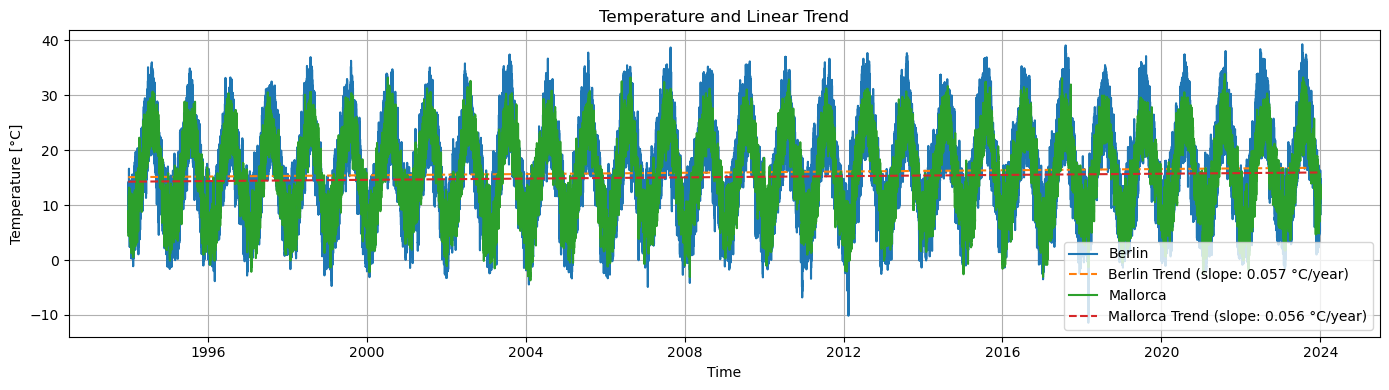

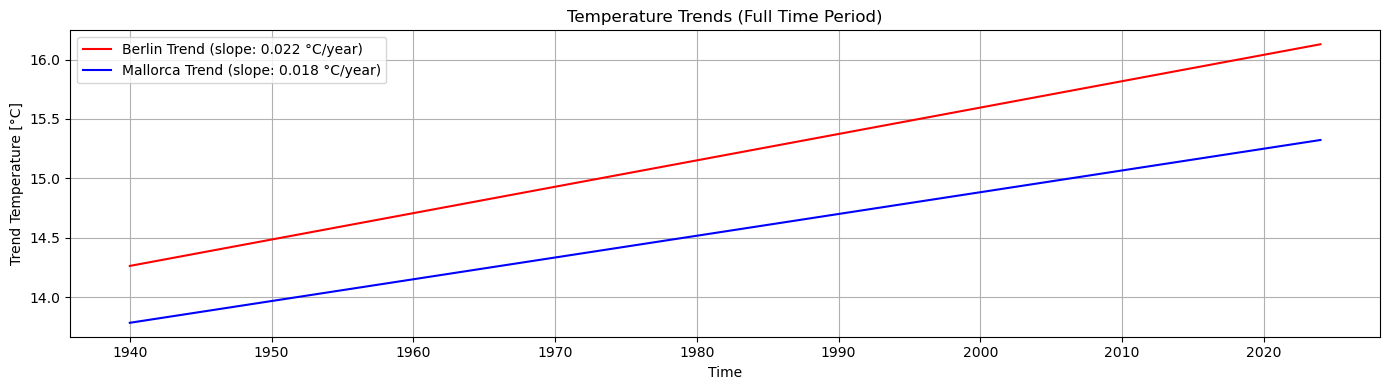

Mallorca trend slope: 0.000050 °C/day (0.018 °C/year)
City 2 trend slope: 0.000061 °C/day (0.022 °C/year)


In [9]:
# --- Prints the Slope of the trend of the past 30 yrs ---
time1_30yrs, trend1_30y, slope1_30y = get_trend(t2m_1_30y, "Mallorca")
time2_30yrs, trend2_30y, slope2_30y = get_trend(t2m_2_30y, "Berlin")
print(f"Mallorca trend slope: {slope1_30y:.6f} °C/day ({slope1_30y*365:.3f} °C/year)")
print(f"Berlin trend slope: {slope2_30y:.6f} °C/day ({slope2_30y*365:.3f} °C/year)")

# --- Plot the Hourly Temperature and the Trend of both Cities ---
plt.figure(figsize=(14, 4))
plot_with_trend(t2m_2_30y, "Berlin", f"Berlin Trend (slope: {slope2_30y*365:.3f} °C/year)")
plot_with_trend(t2m_1_30y, "Mallorca", f"Mallorca Trend (slope: {slope1_30y*365:.3f} °C/year)")
plt.title("Temperature and Linear Trend")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('01_Temperature_Trend_Mal_Ber.png', dpi=300)
plt.show()


# --- Get the trend of the whole time series ---
time1, trend1, slope1 = get_trend(t2m_1, "Mallorca")
time2, trend2, slope2 = get_trend(t2m_2, "Berlin")

# --- Plot the trend of the whole time series ---
plt.figure(figsize=(14, 4))
plt.plot(time2, trend2, label=f"Berlin Trend (slope: {slope2*365:.3f} °C/year)", color="red")
plt.plot(time1, trend1, label=f"Mallorca Trend (slope: {slope1*365:.3f} °C/year)", color="blue")
plt.title("Temperature Trends (Full Time Period)")
plt.xlabel("Time")
plt.ylabel("Trend Temperature [°C]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('02_Trend_mall_ber_1958.png', dpi=300)
plt.show()

# --- Print slopes numerically ---
print(f"Mallorca trend slope: {slope1:.6f} °C/day ({slope1*365:.3f} °C/year)")
print(f"City 2 trend slope: {slope2:.6f} °C/day ({slope2*365:.3f} °C/year)")



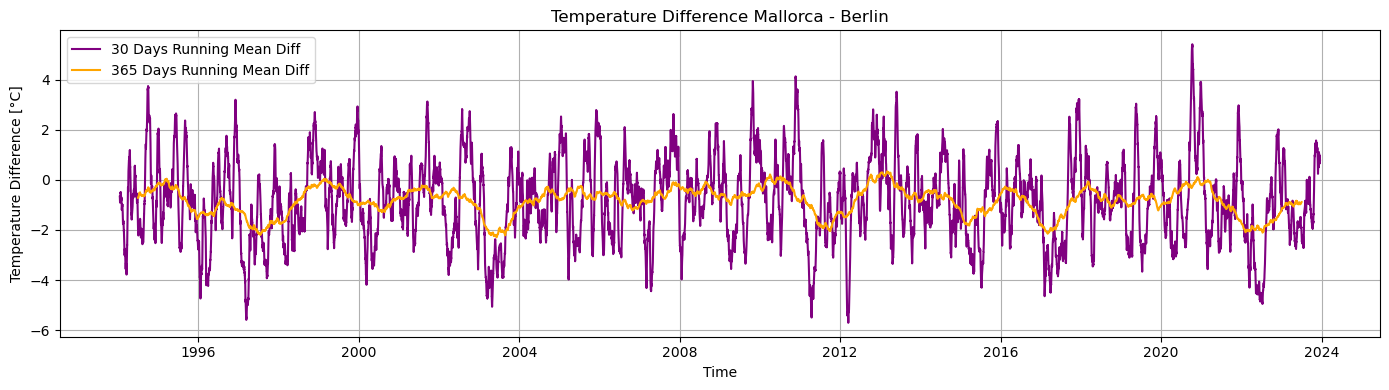

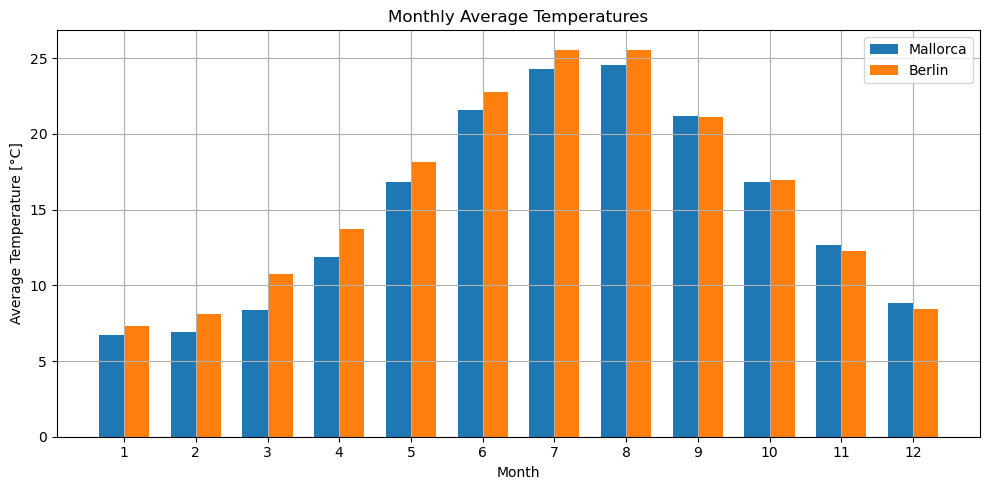

In [10]:
# === 2) 30-year running mean ===
def running_mean(t2m, window_hours):
    return t2m.rolling(time=window_hours, center=True).mean()
    #find out what rolling is

t2m_1_rm_30 = running_mean(t2m_1_30y, 24*30)
t2m_2_rm_30 = running_mean(t2m_2_30y, 24*30)
diff_rm_30 = t2m_1_rm_30 - t2m_2_rm_30

t2m_1_rm_365 = running_mean(t2m_1_30y, 24*365)
t2m_2_rm_365 = running_mean(t2m_2_30y, 24*365)
diff_rm_365 = t2m_1_rm_365 - t2m_2_rm_365


plt.figure(figsize=(14, 4))
plt.plot(diff_rm_30.time, diff_rm_30, label="30 Days Running Mean Diff ", color="purple")
plt.plot(diff_rm_365.time, diff_rm_365, label="365 Days Running Mean Diff", color="Orange")

plt.title("Temperature Difference Mallorca - Berlin")
plt.xlabel("Time")
plt.ylabel("Temperature Difference [°C]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('03_Temp_diff_30_365run.png', dpi=300)
plt.show()

# === 3) Monthly Climatology ===
t2m_1_monthly = t2m_1_30y.groupby("time.month").mean("time")
t2m_2_monthly = t2m_2_30y.groupby("time.month").mean("time")

months = np.arange(1, 13)
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(months - width / 2, t2m_1_monthly, width=width, label="Mallorca")
plt.bar(months + width / 2, t2m_2_monthly, width=width, label="Berlin")
plt.xticks(months)
plt.xlabel("Month")
plt.ylabel("Average Temperature [°C]")
plt.title("Monthly Average Temperatures")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('04_months_average_mall_ber.png', dpi=300)
plt.show()



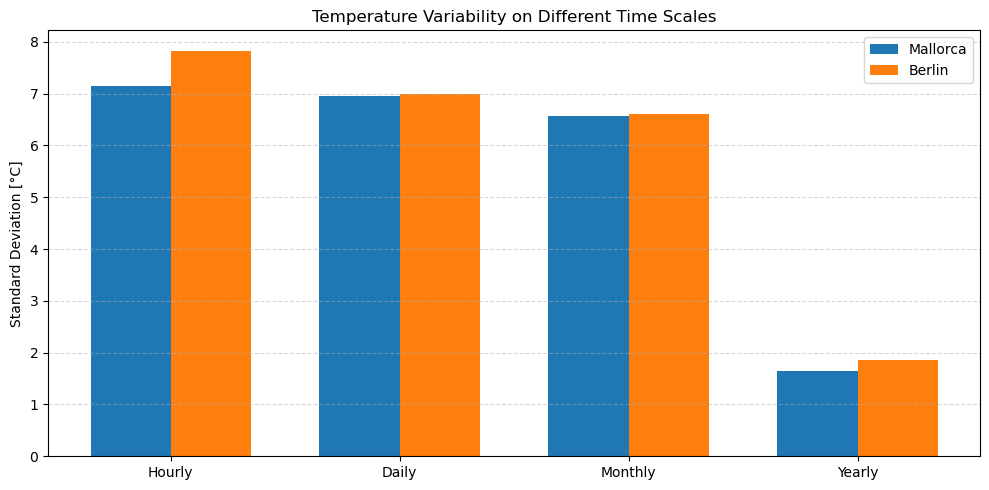

In [13]:
# 1. Hourly standard deviation (original data)
std_hourly_1 = float(t2m_1_30y.std())
std_hourly_2 = float(t2m_2_30y.std())

# 2. Daily standard deviation (24h mean first)
daily_1 = t2m_1_30y.resample(time='1D').mean()
daily_2 = t2m_2_30y.resample(time='1D').mean()
std_daily_1 = float(daily_1.std())
std_daily_2 = float(daily_2.std())

# 3. Monthly standard deviation (monthly mean first)
monthly_1 = t2m_1_30y.resample(time='1ME').mean()
monthly_2 = t2m_2_30y.resample(time='1ME').mean()
std_monthly_1 = float(monthly_1.std())
std_monthly_2 = float(monthly_2.std())

# 4. Yearly standard deviation (yearly mean first)
yearly_1 = t2m_1_30y.resample(time='1YE').mean()
yearly_2 = t2m_2_30y.resample(time='1YE').mean()
std_yearly_1 = float(yearly_1.std())
std_yearly_2 = float(yearly_2.std())

# --- Create Bar Plot ---
labels = ['Hourly', 'Daily', 'Monthly', 'Yearly']
city1_std = [std_hourly_1, std_daily_1, std_monthly_1, std_yearly_1]
city2_std = [std_hourly_2, std_daily_2, std_monthly_2, std_yearly_2]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, city1_std, width, label='Mallorca')
plt.bar(x + width/2, city2_std, width, label='Berlin')

plt.ylabel('Standard Deviation [°C]')
plt.title('Temperature Variability on Different Time Scales')
plt.xticks(x, labels)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('06_variablity_diffrend_timescale_mall_ber.png', dpi=300)
plt.show()


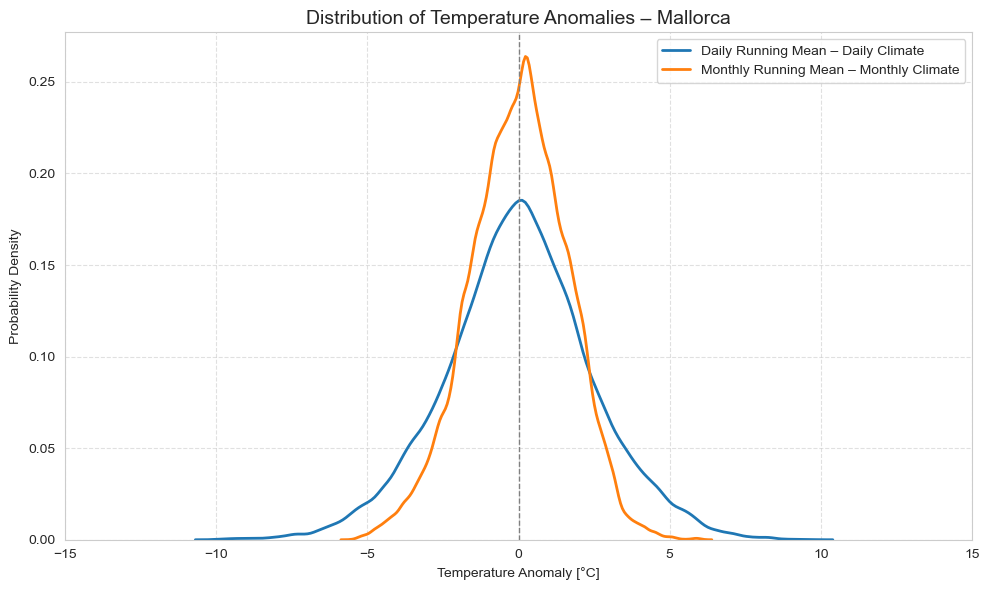

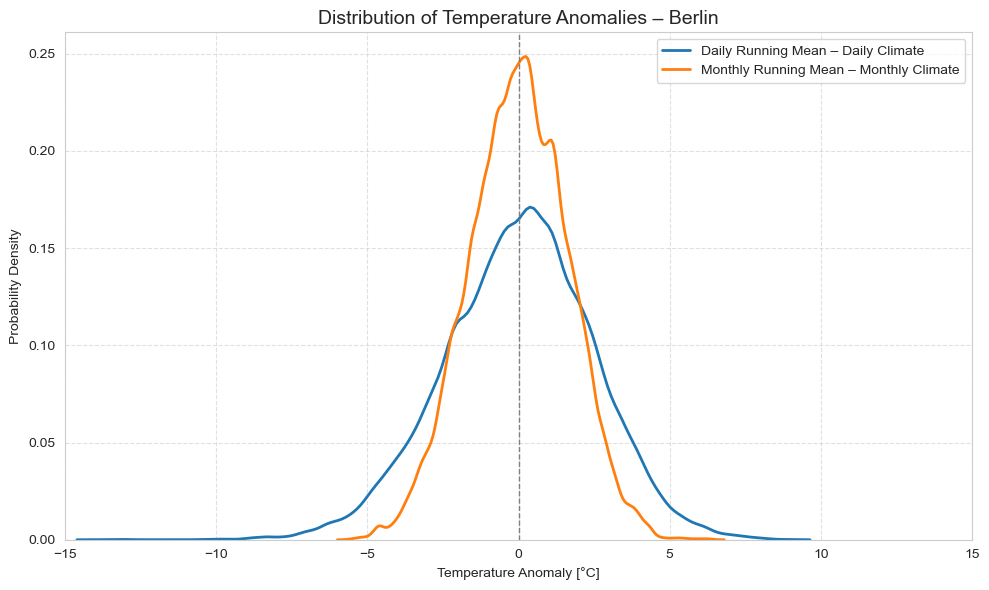

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

def plot_all_anomaly_distributions(t2m, city_name):
    sns.set_style("whitegrid")

    # DAILY anomalies
    t2m_daily_rm = t2m.rolling(time=24, center=True).mean()
    daily_clim = t2m.groupby('time.dayofyear').mean('time')
    daily_anomalies = t2m_daily_rm.groupby('time.dayofyear') - daily_clim
    daily_vals = daily_anomalies.values.flatten()
    daily_vals = daily_vals[~np.isnan(daily_vals)]

    # MONTHLY anomalies
    t2m_monthly_rm = t2m.rolling(time=30 * 24, center=True).mean()
    monthly_clim = t2m.groupby('time.month').mean('time')
    monthly_anomalies = t2m_monthly_rm.groupby('time.month') - monthly_clim
    monthly_vals = monthly_anomalies.values.flatten()
    monthly_vals = monthly_vals[~np.isnan(monthly_vals)]

    # YEARLY anomalies
    t2m_yearly_rm = t2m.rolling(time=365 * 24, center=True).mean()
    yearly_clim = t2m.groupby('time.year').mean('time')
    yearly_anomalies = t2m_yearly_rm.groupby('time.year') - yearly_clim
    yearly_vals = yearly_anomalies.values.flatten()
    yearly_vals = yearly_vals[~np.isnan(yearly_vals)]

    # PLOT
    plt.figure(figsize=(10, 6))
    sns.kdeplot(daily_vals, label="Daily Running Mean – Daily Climate", linewidth=2)
    sns.kdeplot(monthly_vals, label="Monthly Running Mean – Monthly Climate", linewidth=2)
    #sns.kdeplot(yearly_vals, label="Yearly Running Mean – Yearly Climate", linewidth=2)

    plt.title(f"Distribution of Temperature Anomalies – {city_name}", fontsize=14)
    plt.xlabel("Temperature Anomaly [°C]")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.axvline(0, color='gray', linestyle='--', linewidth=1)
    plt.xlim(-15, 15)  # <-- Center x-axis from -15°C to +15°C
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    title1 = f"Distribution of Temperature Anomalies – {city_name}"
    filename = f"{title1.replace(' ', '_').replace(':', '')}.png"
    plt.savefig(filename, dpi=300)
    plt.show()

# Use the function for both cities
plot_all_anomaly_distributions(t2m_1_30y, "Mallorca")
plot_all_anomaly_distributions(t2m_2_30y, "Berlin")


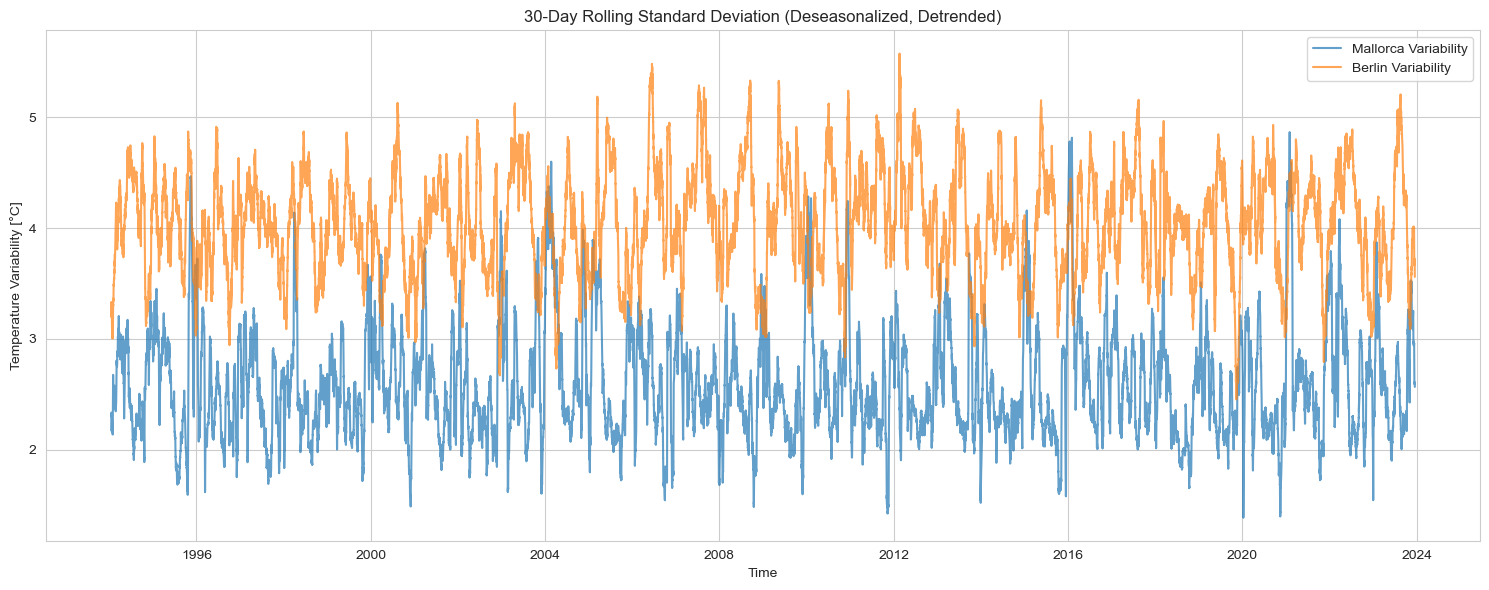

In [16]:
# Compute deseasonalized and detrended variability for both cities

def deseasonalize_and_detrend(t2m):
    # Calculate the daily climatology (mean for each day of year across all years)
    climatology = t2m.groupby("time.dayofyear").mean("time")
    deseasonalized = t2m.groupby("time.dayofyear") - climatology

    # Detrend (remove linear trend)
    times = deseasonalized.time.values.astype('datetime64[h]').astype(float)
    slope, intercept, _, _, _ = linregress(times, deseasonalized.values)
    trend = slope * times + intercept
    detrended = deseasonalized - trend

    return detrended

# Apply to both cities
detrended_1 = deseasonalize_and_detrend(t2m_1_30y)
detrended_2 = deseasonalize_and_detrend(t2m_2_30y)

# Compute 30-day rolling standard deviation as a measure of variability
rolling_sd_1 = detrended_1.rolling(time=24*30, center=True).std()
rolling_sd_2 = detrended_2.rolling(time=24*30, center=True).std()

# Plot the variability for both cities
plt.figure(figsize=(15, 6))
plt.plot(rolling_sd_1.time, rolling_sd_1, label='Mallorca Variability', alpha=0.7)
plt.plot(rolling_sd_2.time, rolling_sd_2, label='Berlin Variability', alpha=0.7)
plt.title("30-Day Rolling Standard Deviation (Deseasonalized, Detrended)")
plt.xlabel("Time")
plt.ylabel("Temperature Variability [°C]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('11_30d_std_deseason.png', dpi=300)
plt.show()


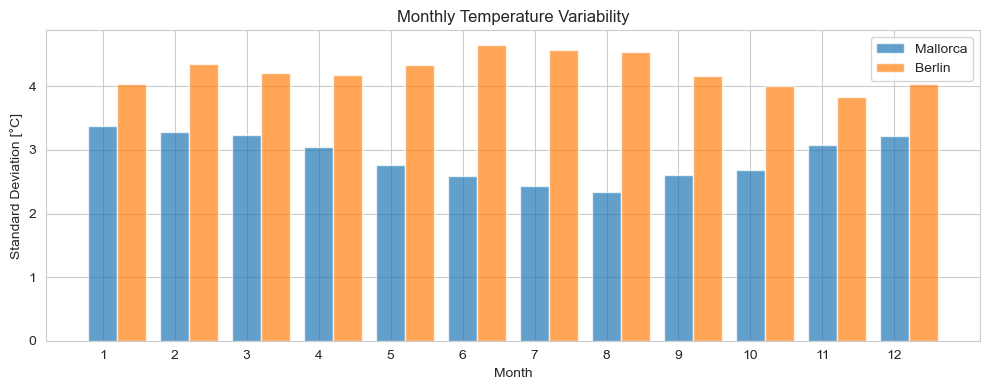

In [18]:
# --- Monthly Standard Deviation ---
std_monthly_city1 = detrended_1.groupby("time.month").std()
std_monthly_city2 = detrended_2.groupby("time.month").std()

plt.figure(figsize=(10, 4))
plt.bar(std_monthly_city1['month'], std_monthly_city1, width=0.4, label="Mallorca", alpha=0.7)
plt.bar(std_monthly_city2['month'] + 0.4, std_monthly_city2, width=0.4, label="Berlin", alpha=0.7)
plt.xticks(range(1, 13))
plt.xlabel('Month')
plt.ylabel('Standard Deviation [°C]')
plt.title('Monthly Temperature Variability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('12_months_std_mall_ber.png', dpi=300)
plt.show()

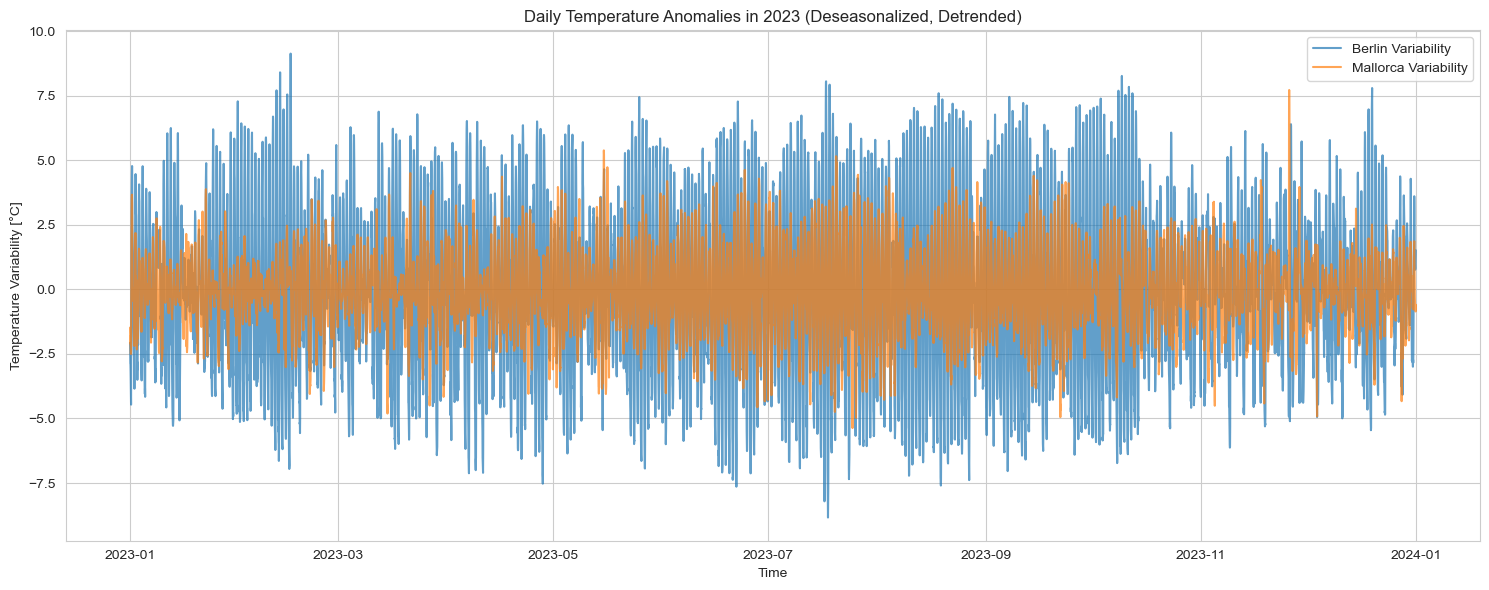

In [21]:
last_date = pd.to_datetime(t2m_1_30y.time.values[-1])
year_start = pd.to_datetime(f"{last_date.year}-01-01")
year_end = pd.to_datetime(f"{last_date.year}-12-31T23:00")
t2m_1_2023 = t2m_1_30y.sel(time=slice(year_start, year_end))

last_date = pd.to_datetime(t2m_2_30y.time.values[-1])
year_start = pd.to_datetime(f"{last_date.year}-01-01")
year_end = pd.to_datetime(f"{last_date.year}-12-31T23:00")
t2m_2_2023 = t2m_2_30y.sel(time=slice(year_start, year_end))


# Apply to both cities
#daily
detrended_1_2023 = deseasonalize_and_detrend(t2m_1_2023)
detrended_2_2023 = deseasonalize_and_detrend(t2m_2_2023)


# Plot the variability for both cities
plt.figure(figsize=(15, 6))
plt.plot(detrended_2_2023.time, detrended_2_2023, label='Berlin Variability', alpha=0.7)
plt.plot(detrended_1_2023.time, detrended_1_2023, label='Mallorca Variability', alpha=0.7)
plt.title("Daily Temperature Anomalies in 2023 (Deseasonalized, Detrended)")
plt.xlabel("Time")
plt.ylabel("Temperature Variability [°C]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('13_variability_2023_deseason.png', dpi=300)
plt.show()

/var/folders/xl/99tg9s3x1f325d223ch6jyx80000gn/T/ipykernel_13635/1324089398.py:18: RuntimeWarning: divide by zero encountered in divide
  period1 = 1 / f1
/var/folders/xl/99tg9s3x1f325d223ch6jyx80000gn/T/ipykernel_13635/1324089398.py:19: RuntimeWarning: divide by zero encountered in divide
  period2 = 1 / f2


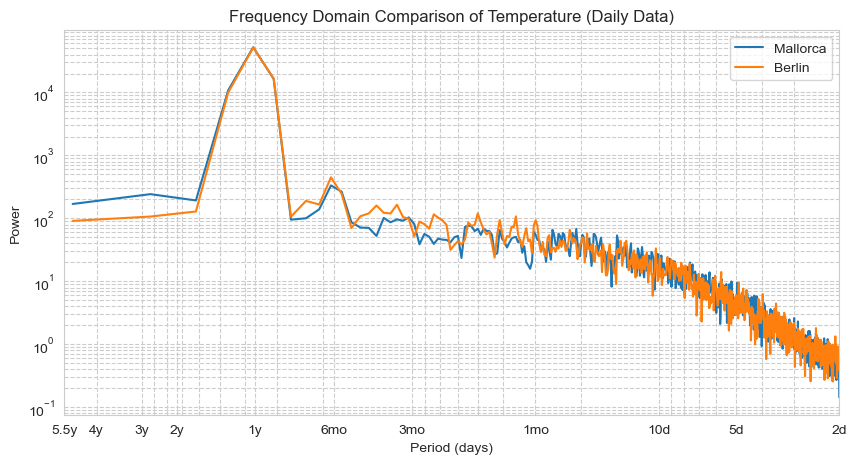

In [22]:


t2m_daily_1 = t2m_1_30y.resample(time='1D').mean()
t2m_daily_2 = t2m_2_30y.resample(time='1D').mean()

ts1 = t2m_daily_1.values.flatten()
ts2 = t2m_daily_2.values.flatten()

# Remove NaNs if any
ts1 = ts1[~np.isnan(ts1)]
ts2 = ts2[~np.isnan(ts2)]

fs = 1  # sampling frequency (1/day for daily data, 1/hour for hourly data)

# Welch method gives a smooth estimate of the power spectrum
f1, Pxx1 = welch(ts1, fs=fs, nperseg=1856)
f2, Pxx2 = welch(ts2, fs=fs, nperseg=1856)

# Convert frequency to period (e.g., days)
period1 = 1 / f1
period2 = 1 / f2

plt.figure(figsize=(10, 5))
plt.plot(period1, Pxx1, label='Mallorca')
plt.plot(period2, Pxx2, label='Berlin')
plt.xlabel('Period (days)')
plt.ylabel('Power')
plt.title('Frequency Domain Comparison of Temperature (Daily Data)')
plt.yscale('log')
plt.xscale('log')
plt.xlim(2, 2000)  # from 2 to 2000 days
plt.xticks([2, 5, 10, 30, 90, 180, 365, 730, 1000, 1500, 2000],
           ['2d', '5d', '10d', '1mo', '3mo', '6mo', '1y', '2y', '3y', '4y', '5.5y'])

plt.grid(True, which='both', linestyle='--')
plt.legend()
plt.gca().invert_xaxis()  # so long periods (low freq) are on the left
plt.savefig('14_frequency_domain_daily.png', dpi=300)

plt.show()



/var/folders/xl/99tg9s3x1f325d223ch6jyx80000gn/T/ipykernel_13635/3495437172.py:7: RuntimeWarning: divide by zero encountered in divide
  period1 = 1 / f1
/var/folders/xl/99tg9s3x1f325d223ch6jyx80000gn/T/ipykernel_13635/3495437172.py:8: RuntimeWarning: divide by zero encountered in divide
  period2 = 1 / f2


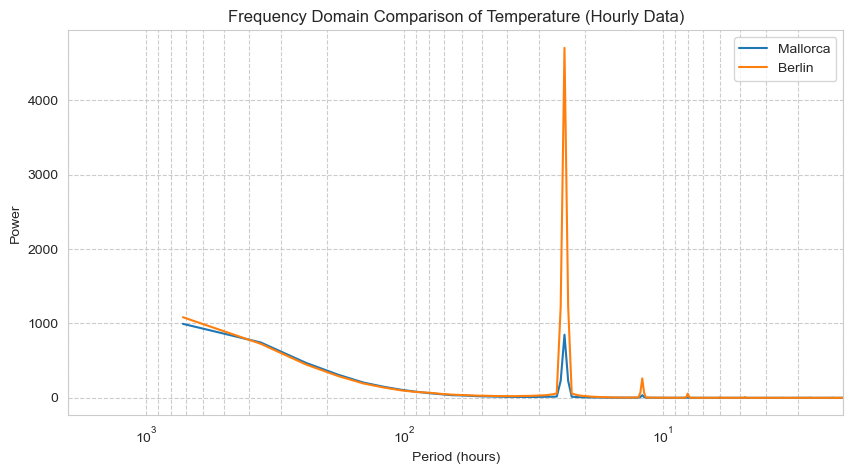

In [25]:
### Hours
# Welch method gives a smooth estimate of the power spectrum
f1, Pxx1 = welch(t2m_1_30y, fs=fs, nperseg=30*24)
f2, Pxx2 = welch(t2m_2_30y, fs=fs, nperseg=30*24)

# Convert frequency to period (e.g., days)
period1 = 1 / f1
period2 = 1 / f2



plt.figure(figsize=(10, 5))
plt.plot(period1, Pxx1, label='Mallorca')
plt.plot(period2, Pxx2, label='Berlin')
plt.xlabel('Period (hours)')
plt.ylabel('Power')
plt.title('Frequency Domain Comparison of Temperature (Hourly Data)')
plt.xscale('log')
plt.xlim(2, 2000)  # from 2 to 2000 days
plt.grid(True, which='both', linestyle='--')
plt.legend()
plt.gca().invert_xaxis()  # so long periods (low freq) are on the left
plt.savefig('15_frequency_domain_hourly.png', dpi=300)

plt.show()
